<a href="https://colab.research.google.com/github/aditijagtap19/Aditi.Ads/blob/main/AI_Investment_Advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Install necessary libraries
!pip install pandas numpy matplotlib seaborn scikit-learn nltk pdfplumber requests

# Step 2: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import requests
import nltk
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Download NLP data
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 48.3 MB/s eta 0:00:00
✅ All libraries installed successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
# Step 3: Create sample mutual fund data
def create_sample_fund_data():
    funds = {
        'fund_name': [
            'Axis Bluechip Fund', 'HDFC Top 100 Fund', 'ICICI Pru Technology Fund',
            'Axis Midcap Fund', 'HDFC Balanced Advantage Fund', 'ICICI Pru Value Discovery',
            'Axis Smallcap Fund', 'HDFC Multicap Fund', 'ICICI Pru Banking Fund'
        ],
        'amc': ['Axis', 'HDFC', 'ICICI', 'Axis', 'HDFC', 'ICICI', 'Axis', 'HDFC', 'ICICI'],
        'category': ['Large Cap', 'Large Cap', 'Sectoral', 'Mid Cap', 'Hybrid', 'Value', 'Small Cap', 'Multi Cap', 'Sectoral'],
        'risk_level': [2, 2, 4, 3, 2, 3, 5, 3, 4],  # 1=Low, 5=High
        'min_investment_horizon': [5, 5, 4, 5, 3, 5, 7, 5, 4],  # in years
        'expense_ratio': [1.2, 1.35, 1.1, 1.4, 1.25, 1.3, 1.5, 1.35, 1.2],
        'returns_1yr': [12.5, 11.8, 25.3, 18.2, 10.5, 15.7, 28.9, 14.3, 22.1],
        'returns_3yr': [15.2, 14.8, 22.1, 19.5, 12.3, 16.8, 24.3, 16.2, 20.5],
        'volatility': [12.3, 13.1, 18.5, 16.2, 10.8, 14.3, 22.7, 15.1, 17.8],
        'sharpe_ratio': [1.23, 1.13, 1.20, 1.18, 1.14, 1.17, 1.07, 1.07, 1.15],
        'aum_crores': [24500, 18700, 8200, 12500, 32500, 14200, 6800, 15600, 7200]
    }

    return pd.DataFrame(funds)

# Create the dataframe
funds_df = create_sample_fund_data()
print("📊 Sample Fund Data Created!")
print(funds_df)

📊 Sample Fund Data Created!
                      fund_name    amc   category  risk_level  \
0            Axis Bluechip Fund   Axis  Large Cap           2   
1             HDFC Top 100 Fund   HDFC  Large Cap           2   
2     ICICI Pru Technology Fund  ICICI   Sectoral           4   
3              Axis Midcap Fund   Axis    Mid Cap           3   
4  HDFC Balanced Advantage Fund   HDFC     Hybrid           2   
5     ICICI Pru Value Discovery  ICICI      Value           3   
6            Axis Smallcap Fund   Axis  Small Cap           5   
7            HDFC Multicap Fund   HDFC  Multi Cap           3   
8        ICICI Pru Banking Fund  ICICI   Sectoral           4   

   min_investment_horizon  expense_ratio  returns_1yr  returns_3yr  \
0                       5           1.20         12.5         15.2   
1                       5           1.35         11.8         14.8   
2                       4           1.10         25.3         22.1   
3                       5           1.40 

In [4]:
# Step 4: User Risk Assessment Questionnaire
def risk_assessment_quiz():
    print("🎯 Welcome to AI Investment Advisor!")
    print("Please answer the following questions:\n")

    questions = [
        "What is your age? (1: <25, 2: 25-35, 3: 35-50, 4: >50): ",
        "What is your investment goal? (1: Safety, 2: Income, 3: Balanced, 4: Growth, 5: Aggressive Growth): ",
        "What is your investment horizon? (1: <2 years, 2: 2-5 years, 3: 5-7 years, 4: >7 years): ",
        "How would you react to a 20% market drop? (1: Sell everything, 2: Sell some, 3: Hold, 4: Buy more): ",
        "What percentage of income do you invest? (1: <10%, 2: 10-20%, 3: 20-30%, 4: >30%): "
    ]

    answers = []
    for question in questions:
        while True:
            try:
                answer = int(input(question))
                if 1 <= answer <= 5:
                    answers.append(answer)
                    break
                else:
                    print("Please enter a number between 1-5")
            except:
                print("Please enter a valid number")

    # Calculate risk score (1-5)
    risk_score = sum(answers) / len(answers)
    risk_level = min(5, max(1, round(risk_score)))

    risk_labels = {1: 'Conservative', 2: 'Moderately Conservative',
                   3: 'Moderate', 4: 'Moderately Aggressive', 5: 'Aggressive'}

    print(f"\n📈 Your Risk Profile: {risk_labels[risk_level]} (Score: {risk_level})")

    return {
        'risk_score': risk_level,
        'investment_horizon': answers[2],
        'age_group': answers[0],
        'goal': answers[1]
    }

# Run the quiz (uncomment the next line when you're ready to test)
# user_profile = risk_assessment_quiz()

In [5]:
# Step 5: AI Fund Recommendation Engine
def recommend_funds(user_profile, funds_data):
    print("\n🤖 AI Generating Recommendations...")

    risk_score = user_profile['risk_score']
    investment_horizon = user_profile['investment_horizon']

    # Convert horizon to actual years
    horizon_years_map = {1: 2, 2: 3.5, 3: 6, 4: 8}
    min_horizon_years = horizon_years_map[investment_horizon]

    # Filter funds based on risk and horizon
    suitable_funds = funds_data[
        (abs(funds_data['risk_level'] - risk_score) <= 1) &  # Risk tolerance ±1
        (funds_data['min_investment_horizon'] <= min_horizon_years + 2)  # Horizon match
    ].copy()

    if len(suitable_funds) == 0:
        print("No suitable funds found. Broadening search...")
        suitable_funds = funds_data.copy()

    # Calculate recommendation score
    suitable_funds['recommendation_score'] = (
        (5 - abs(suitable_funds['risk_level'] - risk_score)) * 0.3 +
        (suitable_funds['sharpe_ratio'] / suitable_funds['sharpe_ratio'].max()) * 0.4 +
        (1 - (abs(suitable_funds['min_investment_horizon'] - min_horizon_years) /
              suitable_funds['min_investment_horizon'].max())) * 0.3
    )

    # Sort by recommendation score
    recommended_funds = suitable_funds.sort_values('recommendation_score', ascending=False)

    return recommended_funds.head(5)  # Return top 5 recommendations

# Test with a sample profile
sample_profile = {'risk_score': 3, 'investment_horizon': 3, 'age_group': 2, 'goal': 3}
recommendations = recommend_funds(sample_profile, funds_df)

print("🏆 Top 5 Recommended Funds:")
print(recommendations[['fund_name', 'amc', 'category', 'risk_level', 'recommendation_score']])


🤖 AI Generating Recommendations...
🏆 Top 5 Recommended Funds:
                   fund_name    amc   category  risk_level  \
3           Axis Midcap Fund   Axis    Mid Cap           3   
5  ICICI Pru Value Discovery  ICICI      Value           3   
7         HDFC Multicap Fund   HDFC  Multi Cap           3   
0         Axis Bluechip Fund   Axis  Large Cap           2   
1          HDFC Top 100 Fund   HDFC  Large Cap           2   

   recommendation_score  
3              2.123740  
5              2.120488  
7              2.087967  
0              1.840000  
1              1.807480  



💼 Suggested Portfolio Allocation (₹100,000 investment):
                        Fund    AMC   Category  Allocation %  Amount (₹)  \
0           Axis Midcap Fund   Axis    Mid Cap          21.3       21281   
1  ICICI Pru Value Discovery  ICICI      Value          21.2       21248   
2         HDFC Multicap Fund   HDFC  Multi Cap          20.9       20922   
3         Axis Bluechip Fund   Axis  Large Cap          18.4       18437   
4          HDFC Top 100 Fund   HDFC  Large Cap          18.1       18112   

   Risk Level  
0           3  
1           3  
2           3  
3           2  
4           2  


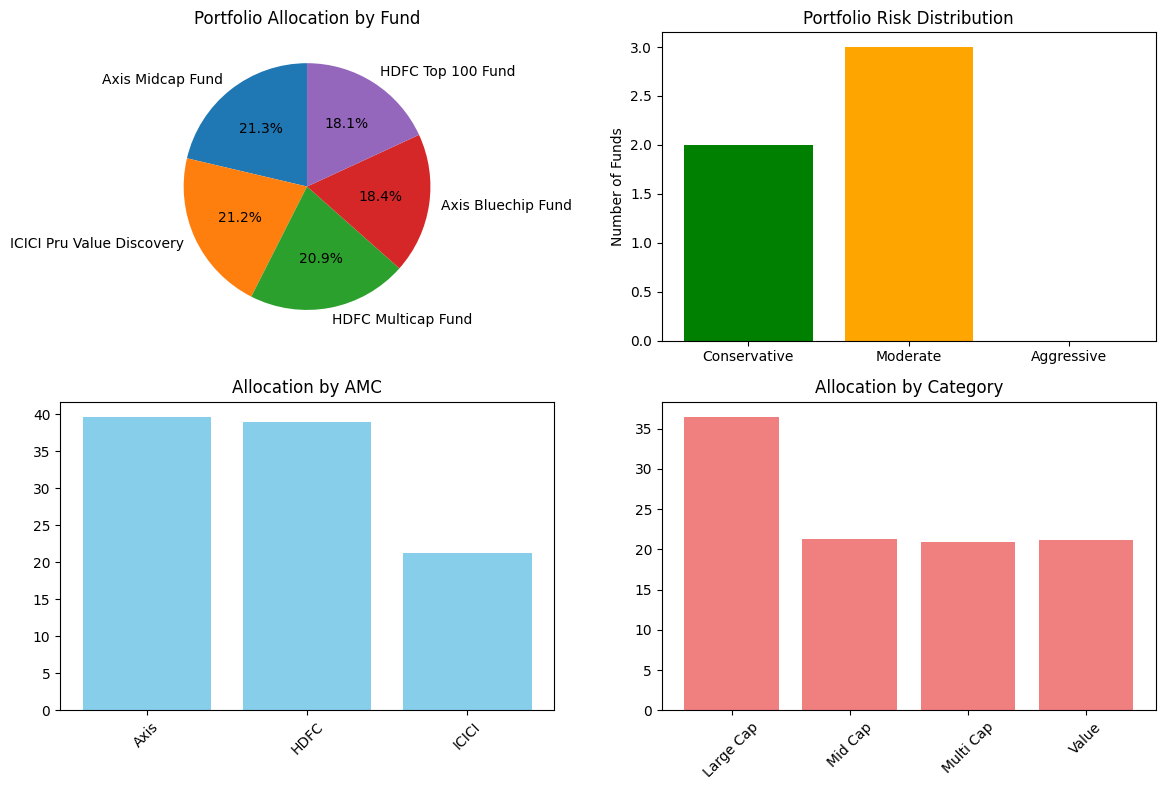

In [6]:
# Step 6: Portfolio Allocation Calculator
def create_portfolio_allocation(recommended_funds, total_investment=100000):
    print(f"\n💼 Suggested Portfolio Allocation (₹{total_investment:,} investment):")

    # Simple allocation based on recommendation score
    total_score = recommended_funds['recommendation_score'].sum()
    recommended_funds = recommended_funds.copy()

    portfolio = []
    for _, fund in recommended_funds.iterrows():
        allocation_pct = (fund['recommendation_score'] / total_score) * 100
        allocation_amt = (allocation_pct / 100) * total_investment

        portfolio.append({
            'Fund': fund['fund_name'],
            'AMC': fund['amc'],
            'Category': fund['category'],
            'Allocation %': round(allocation_pct, 1),
            'Amount (₹)': round(allocation_amt),
            'Risk Level': fund['risk_level']
        })

    portfolio_df = pd.DataFrame(portfolio)
    print(portfolio_df)

    # Create visualization
    plt.figure(figsize=(12, 8))

    # Pie chart for allocation
    plt.subplot(2, 2, 1)
    plt.pie(portfolio_df['Allocation %'], labels=portfolio_df['Fund'], autopct='%1.1f%%', startangle=90)
    plt.title('Portfolio Allocation by Fund')

    # Bar chart for risk distribution
    plt.subplot(2, 2, 2)
    risk_labels = ['Conservative', 'Moderate', 'Aggressive']
    risk_counts = [
        len(portfolio_df[portfolio_df['Risk Level'] <= 2]),
        len(portfolio_df[(portfolio_df['Risk Level'] > 2) & (portfolio_df['Risk Level'] <= 4)]),
        len(portfolio_df[portfolio_df['Risk Level'] > 4])
    ]
    plt.bar(risk_labels, risk_counts, color=['green', 'orange', 'red'])
    plt.title('Portfolio Risk Distribution')
    plt.ylabel('Number of Funds')

    # AMC distribution
    plt.subplot(2, 2, 3)
    amc_distribution = portfolio_df.groupby('AMC')['Allocation %'].sum()
    plt.bar(amc_distribution.index, amc_distribution.values, color='skyblue')
    plt.title('Allocation by AMC')
    plt.xticks(rotation=45)

    # Category distribution
    plt.subplot(2, 2, 4)
    category_distribution = portfolio_df.groupby('Category')['Allocation %'].sum()
    plt.bar(category_distribution.index, category_distribution.values, color='lightcoral')
    plt.title('Allocation by Category')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return portfolio_df

# Create portfolio
portfolio = create_portfolio_allocation(recommendations)

🤖 AI-POWERED INVESTMENT ADVISOR

📊 Loading fund database...

🎯 Welcome to AI Investment Advisor!
Please answer the following questions:

What is your age? (1: <25, 2: 25-35, 3: 35-50, 4: >50): <25
Please enter a valid number
What is your age? (1: <25, 2: 25-35, 3: 35-50, 4: >50): 19
Please enter a number between 1-5
What is your age? (1: <25, 2: 25-35, 3: 35-50, 4: >50): 1
What is your investment goal? (1: Safety, 2: Income, 3: Balanced, 4: Growth, 5: Aggressive Growth): 3
What is your investment horizon? (1: <2 years, 2: 2-5 years, 3: 5-7 years, 4: >7 years): 1
How would you react to a 20% market drop? (1: Sell everything, 2: Sell some, 3: Hold, 4: Buy more): 3
What percentage of income do you invest? (1: <10%, 2: 10-20%, 3: 20-30%, 4: >30%): 1

📈 Your Risk Profile: Moderately Conservative (Score: 2)


🤖 AI Generating Recommendations...

🏆 RECOMMENDED FUNDS:
                      fund_name   amc category  risk_level  returns_1yr  \
4  HDFC Balanced Advantage Fund  HDFC   Hybrid       

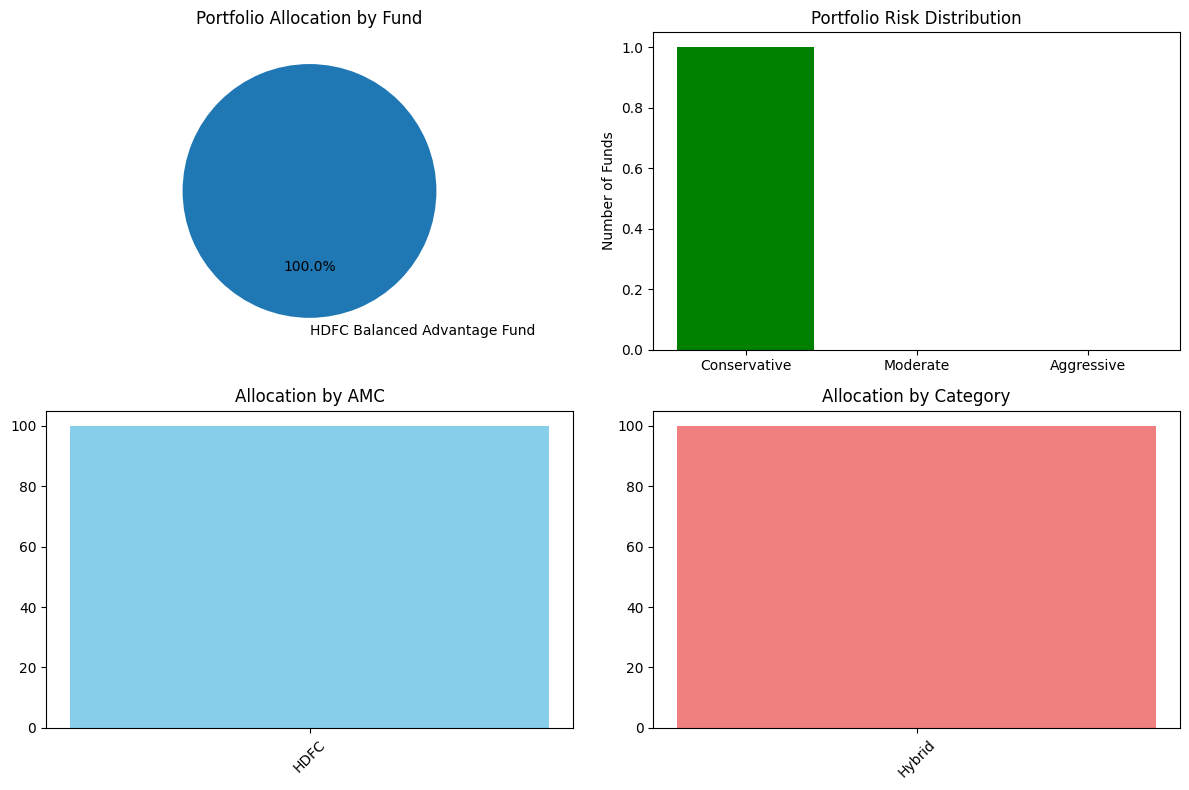


💡 INVESTMENT TIPS:
• Consider SIP (Systematic Investment Plan) for better averaging
• Review your portfolio every 6 months
• Don't panic during market volatility
• Consider tax implications of your investments

✅ Portfolio created successfully! Total funds: 1


In [7]:
# Step 7: Complete Investment Advisor Application
def run_investment_advisor():
    print("=" * 60)
    print("🤖 AI-POWERED INVESTMENT ADVISOR")
    print("=" * 60)

    # Step 1: Load fund data
    print("\n📊 Loading fund database...")
    funds_data = create_sample_fund_data()

    # Step 2: Risk assessment
    print("\n" + "="*40)
    user_profile = risk_assessment_quiz()

    # Step 3: Get recommendations
    print("\n" + "="*40)
    recommendations = recommend_funds(user_profile, funds_data)

    # Step 4: Show recommendations
    print("\n🏆 RECOMMENDED FUNDS:")
    print("=" * 40)
    display_cols = ['fund_name', 'amc', 'category', 'risk_level', 'returns_1yr', 'sharpe_ratio']
    print(recommendations[display_cols].round(2))

    # Step 5: Create portfolio
    print("\n" + "="*40)
    try:
        investment_amount = float(input("\nEnter your investment amount (₹): ") or "100000")
    except:
        investment_amount = 100000
        print(f"Using default amount: ₹{investment_amount:,}")

    portfolio = create_portfolio_allocation(recommendations, investment_amount)

    # Step 6: Investment tips
    print("\n" + "="*40)
    print("💡 INVESTMENT TIPS:")
    print("• Consider SIP (Systematic Investment Plan) for better averaging")
    print("• Review your portfolio every 6 months")
    print("• Don't panic during market volatility")
    print("• Consider tax implications of your investments")

    print(f"\n✅ Portfolio created successfully! Total funds: {len(portfolio)}")

# Run the complete application
run_investment_advisor()